In [46]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.util import random_noise
from tensorflow.keras.layers import Layer, Conv2D, Add, ReLU, Concatenate, GlobalAveragePooling2D, Multiply, Input, Lambda,  MaxPooling2D, UpSampling2D, Activation
from tensorflow.keras.models import Model
from keras.models import load_model
from tensorflow.keras.saving import register_keras_serializable


In [47]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [48]:

def plot_denoising_results(x_test_noisy, decoded_imgs, x_test, n=10):
    """
    Visualizza n immagini rumorose, le rispettive immagini denoised e quelle originali.
    """
    plt.figure(figsize=(20, 4))
    n = 10
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')
        # Immagine denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Denoised")
        plt.axis('off')
        # Immagine originale
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_test[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()



In [49]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [50]:
# MeanShift: sottrae (o aggiunge) la media RGB
@register_keras_serializable("MeanShift")
class MeanShift(Layer):
    def __init__(self, rgb_mean, sign=-1, **kwargs):
        """
        rgb_mean: tupla con la media dei canali R, G, B.
        sign: -1 per sottrarre la media, 1 per aggiungerla.
        """
        super(MeanShift, self).__init__(**kwargs)
        self.rgb_mean = tf.constant(rgb_mean, dtype=tf.float32)
        self.sign = sign

    def call(self, x):
        # x è atteso in formato (batch, altezza, larghezza, 3)
        # Sfruttiamo Lambda per eseguire l'operazione per ogni elemento
        # Nota: non stiamo scalando per std in questo esempio
        return x + self.sign * self.rgb_mean

# BasicBlock: Conv2D seguita da attivazione ReLU
@register_keras_serializable("BasicBlock")
class BasicBlock(Layer):
    def __init__(self, out_channels, kernel_size=3, stride=1, use_bias=False, **kwargs):
        super(BasicBlock, self).__init__(**kwargs)
        self.conv = Conv2D(out_channels, kernel_size, strides=stride,
                           padding='same', use_bias=use_bias)
        self.relu = ReLU()

    def call(self, x):
        return self.relu(self.conv(x))

# ResidualBlock: due convoluzioni con skip connection(come lavora cuda con 2 thread -> 2 filtri applicati e poi si uniscono i risultati)
@register_keras_serializable("ResidualBlock")
class ResidualBlock(Layer):
    def __init__(self, out_channels, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.conv1 = Conv2D(out_channels, 3, strides=1, padding='same')
        self.relu = ReLU()
        self.conv2 = Conv2D(out_channels, 3, strides=1, padding='same')

    def call(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        out = Add()([x, residual])
        return ReLU()(out)

# EResidualBlock: versione estesa con convoluzioni a gruppi
@register_keras_serializable("EResidualBlock")
class EResidualBlock(Layer):
    def __init__(self, out_channels, groups=1, **kwargs):
        super(EResidualBlock, self).__init__(**kwargs)
        self.conv1 = Conv2D(out_channels, 3, strides=1, padding='same', groups=groups)
        self.relu = ReLU()
        self.conv2 = Conv2D(out_channels, 3, strides=1, padding='same', groups=groups)
        self.conv3 = Conv2D(out_channels, 1, strides=1, padding='valid')

    def call(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        residual = self.relu(residual)
        residual = self.conv3(residual)
        out = Add()([x, residual])
        return ReLU()(out)

# Merge_Run_dual: due rami convoluzionali con dilatazioni diverse, poi fusione e skip connection
@register_keras_serializable("MergeRunDual")
class MergeRunDual(Layer):
    def __init__(self, out_channels, **kwargs):
        super(MergeRunDual, self).__init__(**kwargs)
        # Primo ramo
        self.conv1a = Conv2D(out_channels, 3, strides=1, padding='same')
        self.relu1a = ReLU()
        self.conv1b = Conv2D(out_channels, 3, strides=1, padding='same', dilation_rate=2)
        self.relu1b = ReLU()
        # Secondo ramo
        self.conv2a = Conv2D(out_channels, 3, strides=1, padding='same', dilation_rate=3)
        self.relu2a = ReLU()
        self.conv2b = Conv2D(out_channels, 3, strides=1, padding='same', dilation_rate=4)
        self.relu2b = ReLU()
        # Gogeta
        self.conv3 = Conv2D(out_channels, 3, strides=1, padding='same')
        self.relu3 = ReLU()

    def call(self, x):
        branch1 = self.relu1a(self.conv1a(x))
        branch1 = self.relu1b(self.conv1b(branch1))

        branch2 = self.relu2a(self.conv2a(x))
        branch2 = self.relu2b(self.conv2b(branch2))

        merged = Concatenate()([branch1, branch2])
        merged = self.relu3(self.conv3(merged))
        return Add()([merged, x])

# CALayer: Channel Attention Layer
@register_keras_serializable("CALayer")
class CALayer(Layer):
    def __init__(self, channel, reduction=16, **kwargs):
        super(CALayer, self).__init__(**kwargs)
        self.channel = channel
        self.reduction = reduction
        self.conv1 = Conv2D(channel // reduction, 1, strides=1, padding='same')
        self.relu = ReLU()
        self.conv2 = Conv2D(channel, 1, strides=1, padding='same', activation='sigmoid') #sigmoid: risultato tra 0 e 1

    def call(self, x):
        # Calcolo della media globale per canale
        y = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        y = self.relu(self.conv1(y))
        y = self.conv2(y)
        return Multiply()([x, y])

# Block: combinazione di MergeRunDual, ResidualBlock, EResidualBlock e CALayer
@register_keras_serializable("Block")
class Block(Layer):
    def __init__(self, out_channels, **kwargs):
        super(Block, self).__init__(**kwargs)
        self.merge_run_dual = MergeRunDual(out_channels)
        self.residual_block = ResidualBlock(out_channels)
        self.e_residual_block = EResidualBlock(out_channels)
        self.ca = CALayer(out_channels)

    def call(self, x):
        r1 = self.merge_run_dual(x)
        r2 = self.residual_block(r1)
        r3 = self.e_residual_block(r2)
        out = self.ca(r3)
        return out

# RIDNET: il modello final
@register_keras_serializable("RIDNET")
def RIDNET(n_feats=64, rgb_range=1.0):
    """
    n_feats: numero di feature channels usate all'interno del modello.<br>
    rgb_range: scala dei valori RGB (ad es. 1.0 se l'input è normalizzato [0,1]).
    """
    rgb_mean = (0.4488, 0.4371, 0.4040)

    input_layer = Input(shape=(None, None, 3))

    # Sottosottrai la media (MeanShift con sign=-1)
    sub_mean = MeanShift(rgb_mean, sign=-1)
    x = sub_mean(input_layer)

    # Testa: BasicBlock (conv + ReLU)
    head = Conv2D(n_feats, 3, strides=1, padding='same', activation='relu')(x)

    # Serie di blocchi
    b1 = Block(n_feats)(head)
    b2 = Block(n_feats)(b1)
    b3 = Block(n_feats)(b2)
    b4 = Block(n_feats)(b3)

    # Coda: convoluzione finale per ottenere 3 canali
    tail = Conv2D(3, 3, strides=1, padding='same')(b4)

    # Aggiungi la media (MeanShift con sign=+1)
    add_mean = MeanShift(rgb_mean, sign=1)
    res = add_mean(tail)

    # Connessione residua a livello di immagine: somma con l'input originale
    output = Add()([res, input_layer])

    model = Model(inputs=input_layer, outputs=output)
    return model

In [51]:
def preprocess(sample, img_size=(256, 256)):
    """
    Preprocessa una singola immagine:
      - Normalizza (0, 1)
      - Ridimensiona a img_size
    """
    image = tf.cast(sample['image'], tf.float32) / 255.0
    image = tf.image.resize(image, img_size)
    return image

def load_dataset(split='train', img_size=(256,256), batch_size=16):
    """
    Carica il dataset Oxford-IIIT Pet da tfds e applica il preprocessamento.
    Ritorna un dataset in batch.
    """
    ds_split = 'train[:80%]'
    if(split == 'validation'):
      ds_split = 'train[80%:]'
    elif(split != 'train' or split != 'validation'):
      ds_split = 'test'

    dataset = tfds.load('oxford_iiit_pet', split=ds_split, as_supervised=False)  # as_supervised=False per mantenere dict
    dataset = dataset.map(lambda sample: preprocess(sample, img_size))  # Preprocessing
    dataset = dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Ottimizza il caricamento
    return dataset

In [74]:
# Parametri
img_size = (64, 64)
batch_size = 64
noise_factor = 0.4
epochs = 50

# Caricamento dataset
train_ds = load_dataset(split='train',       img_size=img_size, batch_size=batch_size )
valid_ds = load_dataset( split='validation', img_size=img_size, batch_size=batch_size )
test_ds  = load_dataset(split='test',        img_size=img_size, batch_size=batch_size )

In [53]:
def add_noise_2(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

def add_noise(x):
    noise_levels = [0.1, 0.2, 0.3, 0.4]
    noise_factor = tf.random.shuffle(noise_levels)[0]  # scegli uno random tra i 4
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

In [54]:
train_ds_noisy = train_ds.map(lambda x: (add_noise(x), x))
valid_ds_noisy = valid_ds.map(lambda x: (add_noise(x), x))

test_ds_noisy = test_ds.map(lambda x: (add_noise(x), x))

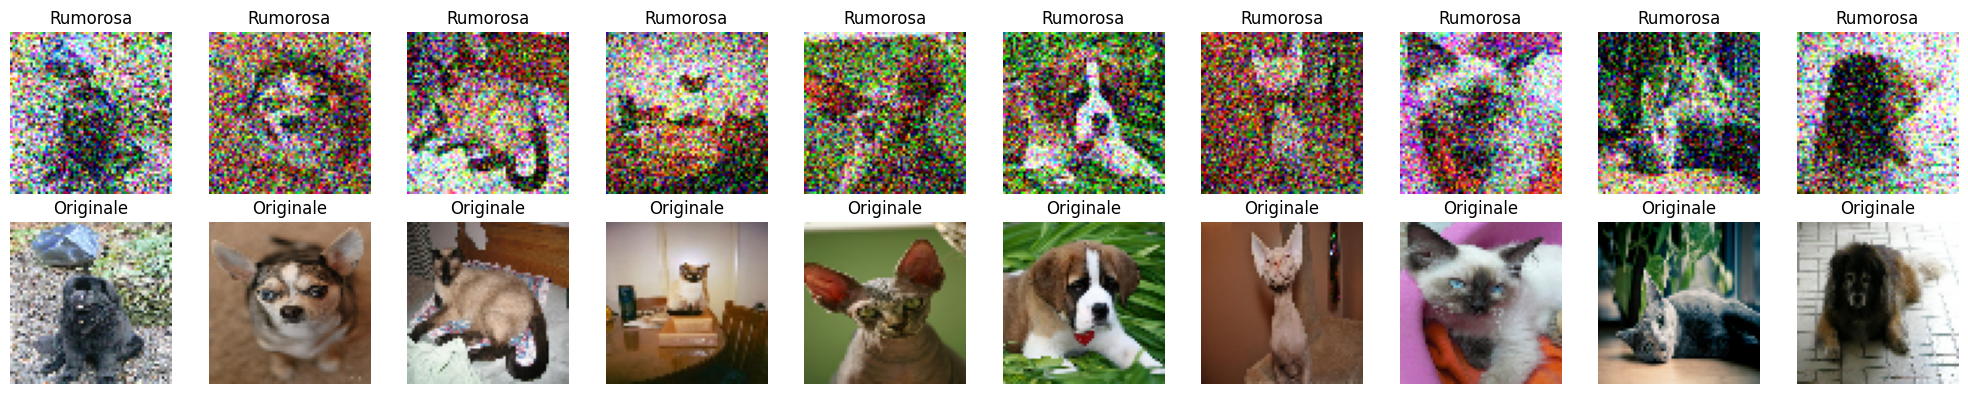

In [55]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(train_ds_noisy))

x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)


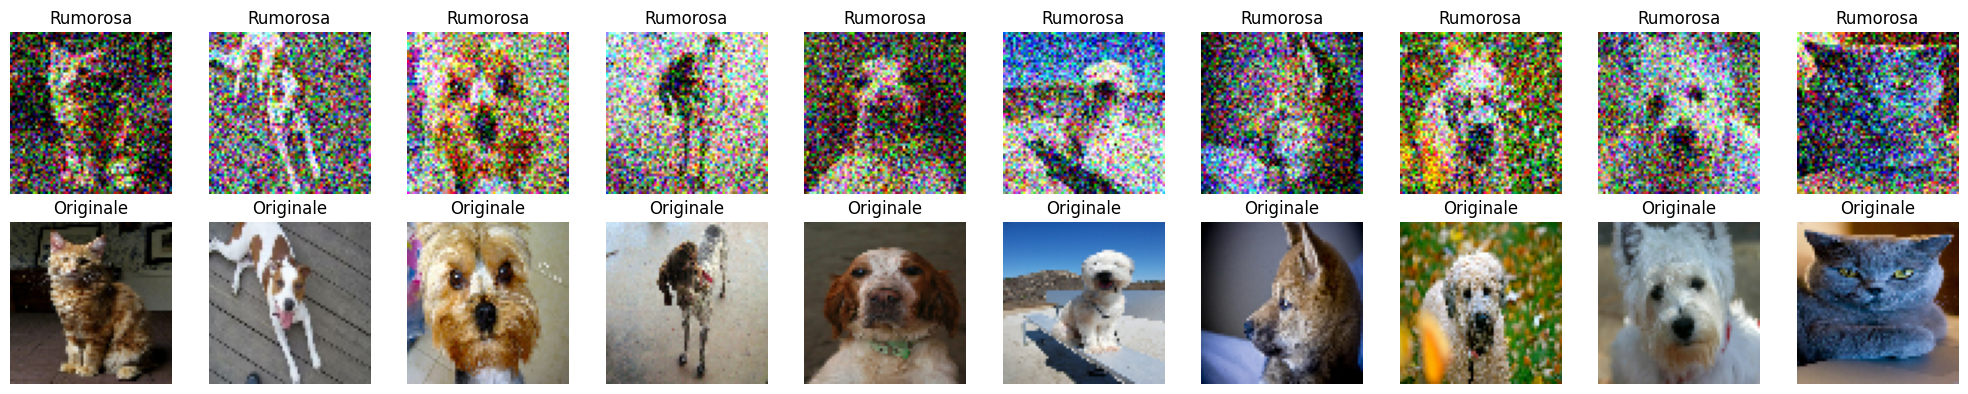

In [56]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)

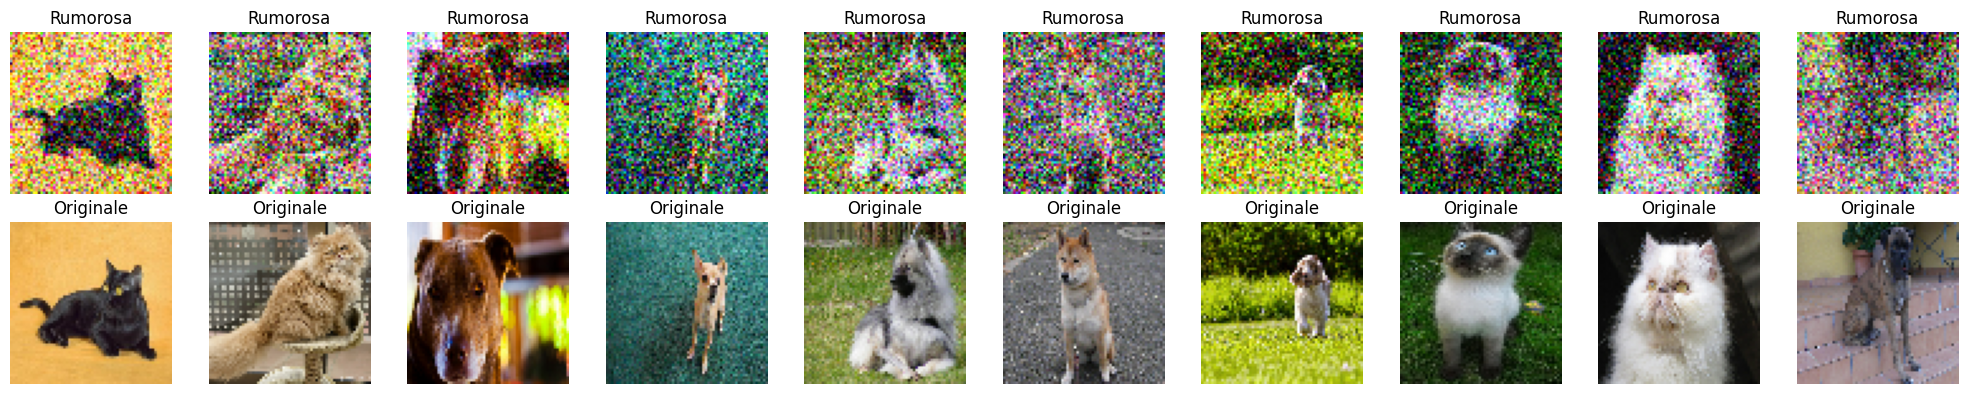

In [57]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np_test = x_noisy_batch.numpy()
x_original_np_test = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np_test, x_original_np_test, n=10)

In [58]:
model = RIDNET(n_feats=32, rgb_range=1.0)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-03), loss=tf.keras.losses.MeanAbsoluteError(), metrics=['accuracy'] )
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_shift_2        │ (None, None,      │          0 │ input_layer_1[0]… │
│ (MeanShift)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, None,      │        896 │ mean_shift_2[0][… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_4 (Block)     │ (None, None,      │     93,666 │ conv2d_61[0][0]   │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_5 (Block)     │ (None, None,      │     93,666 │ block_4[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_6 (Block)     │ (None, None,      │     93,666 │ block_5[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_7 (Block)     │ (None, None,      │     93,666 │ block_6[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, None,      │        867 │ block_7[0][0]     │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_shift_3        │ (None, None,      │          0 │ conv2d_110[0][0]  │
│ (MeanShift)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_124 (Add)       │ (None, None,      │          0 │ mean_shift_3[0][… │
│                     │ None, 3)          │            │ input_layer_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 376,427 (1.44 MB)

 Trainable params: 376,427 (1.44 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
history = model.fit(train_ds_noisy,
              epochs=epochs,
              batch_size=batch_size,
              validation_data=valid_ds_noisy)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 334ms/step - accuracy: 0.6848 - loss: 0.0694 - val_accuracy: 0.6849 - val_loss: 0.0735
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 333ms/step - accuracy: 0.6844 - loss: 0.0710 - val_accuracy: 0.6673 - val_loss: 0.0678
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 345ms/step - accuracy: 0.6850 - loss: 0.0680 - val_accuracy: 0.6788 - val_loss: 0.0625
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 328ms/step - accuracy: 0.6921 - loss: 0.0659 - val_accuracy: 0.6842 - val_loss: 0.0621
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 352ms/step - accuracy: 0.6927 - loss: 0.0651 - val_accuracy: 0.6805 - val_loss: 0.0610
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 330ms/step - accuracy: 0.6976 - loss: 0.0644 - val_accuracy: 0.6943 - val_loss: 0.0664
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 324ms/step - accuracy: 0.6842 - loss: 0.0659 - val_accuracy: 0.7011 - val_loss: 0.0632
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 331ms/step - accuracy: 0.7002 - loss: 0.0630 - val_accu

In [76]:
decoded_imgs = model.predict(x_noisy_np_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


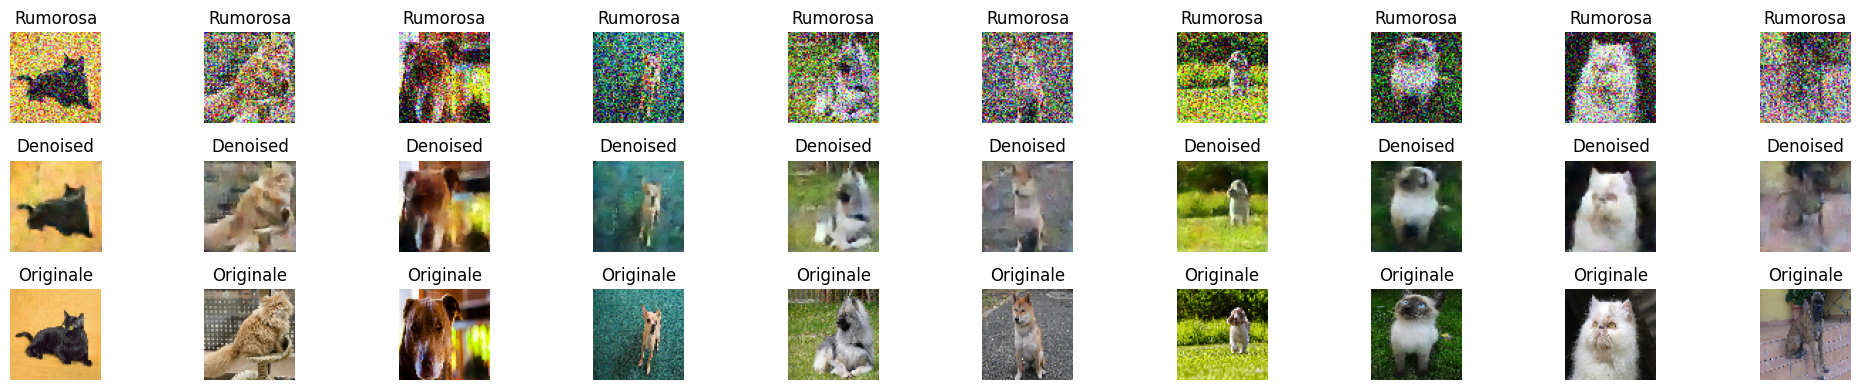

In [77]:
plot_denoising_results(x_noisy_np_test, decoded_imgs, x_original_np_test, n=10)

In [78]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

In [79]:
model.save('new_RIDNET.keras')

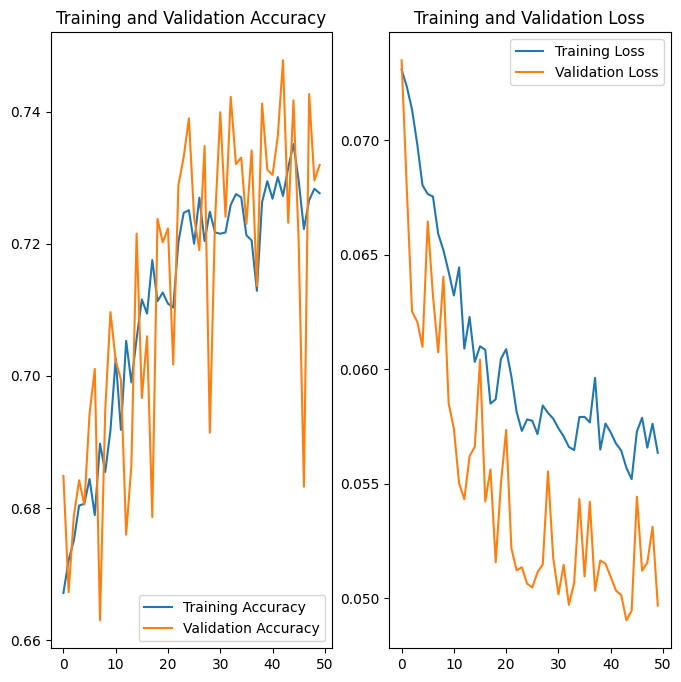

In [80]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [81]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from collections import defaultdict

In [82]:
def calculate_psnr(img1, img2):
    """
    Calcola il PSNR tra due immagini TensorFlow (img1 e img2).
    Entrambe devono essere float32 e normalizzate (0-1) o in uint8 (0-255).
    """
    return tf.image.psnr(img1, img2, max_val=1.0 if img1.dtype.is_floating else 255.0).numpy()

In [83]:
def plot_psnr_vs_noise(psnr_dict):
    levels = sorted(psnr_dict.keys())
    psnr_values = [psnr_dict[level] for level in levels]

    plt.figure(figsize=(8, 5))
    plt.plot(levels, psnr_values, marker='o')
    plt.xlabel("Fattore di rumore")
    plt.ylabel("PSNR medio (dB)")
    plt.title("PSNR vs Livello di Rumore")
    plt.grid(True)
    plt.show()

In [84]:
def psnr_by_noise_level(noisy_images, original_images, noise_levels):
    psnr_dict = defaultdict(list)

    for noisy, original, level in zip(noisy_images, original_images, noise_levels):
        psnr = calculate_psnr(tf.convert_to_tensor(noisy), tf.convert_to_tensor(original))
        psnr_dict[level].append(psnr)

    # Calcola media per ogni livello di rumore
    avg_psnr_by_level = {level: np.mean(values) for level, values in psnr_dict.items()}

    return avg_psnr_by_level

In [85]:
def model_psnr_predict(model, original_images, noise_levels = [0.1, 0.2, 0.3, 0.4]):
  all_a_psnr = []
  for level in noise_levels:
    print("Noise level: " + str(level))
    noisy_images = original_images.map(lambda sample: (add_noise_2(sample, level), sample))

    batch = next(iter(noisy_images))

    x_noisy_batch, x_original_batch = batch

    noisy_np = x_noisy_batch.numpy()
    original_np = x_original_batch.numpy()

    #Ridnet predict psnr
    decoded = model.predict(noisy_np)
    psnrs = [psnr(original_np[i], decoded[i], data_range=original_np[i].max() - original_np[i].min()) for i in range(len(decoded))]
    all_a_psnr.append(np.mean(psnrs))
    plot_denoising_results(noisy_np, decoded, original_np, n=10)
  print (all_a_psnr)
  return all_a_psnr

Noise level: 0.1
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


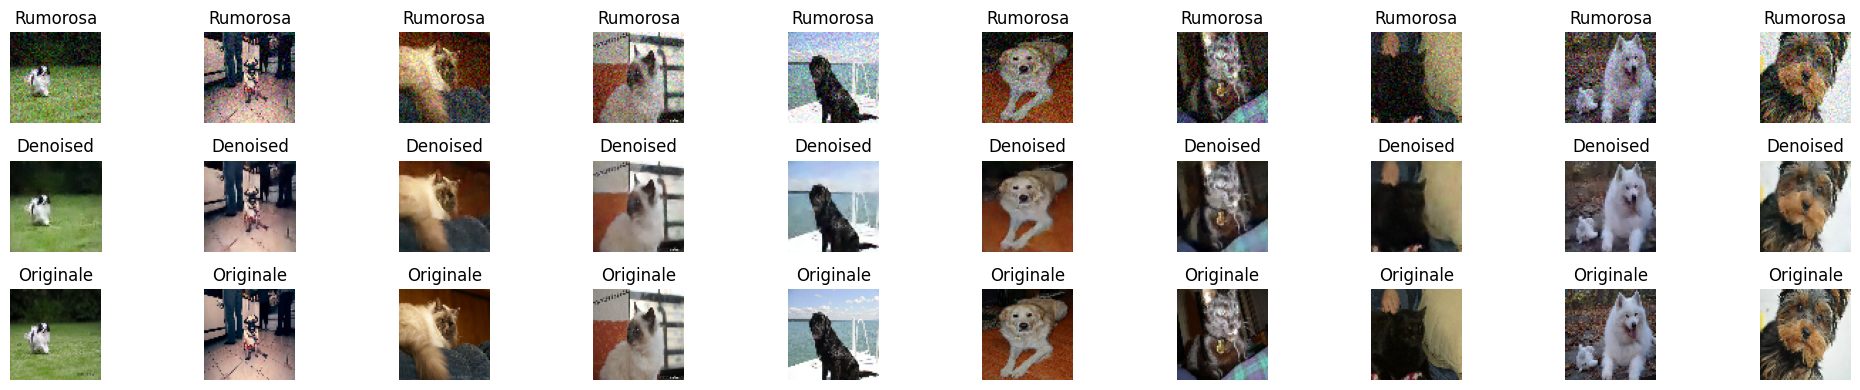

Noise level: 0.2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


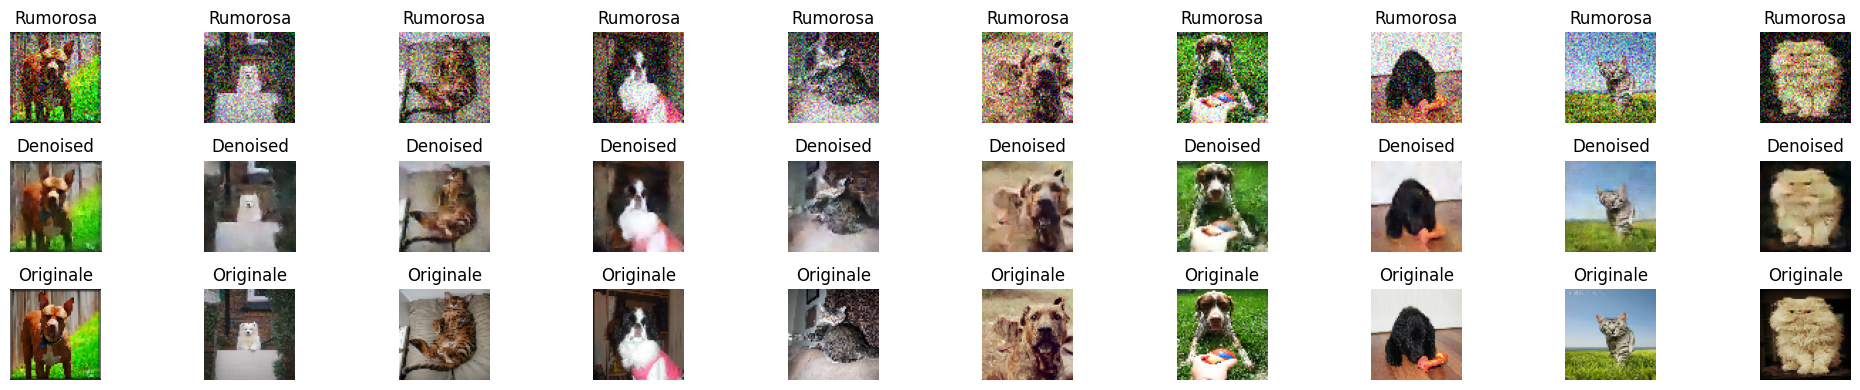

Noise level: 0.3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


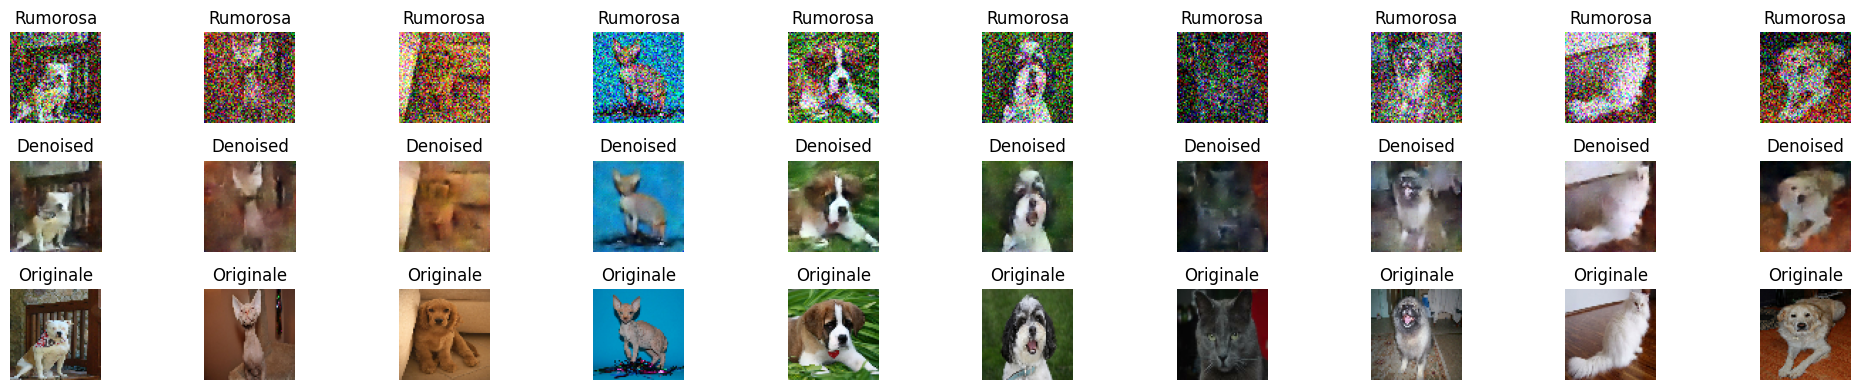

Noise level: 0.4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


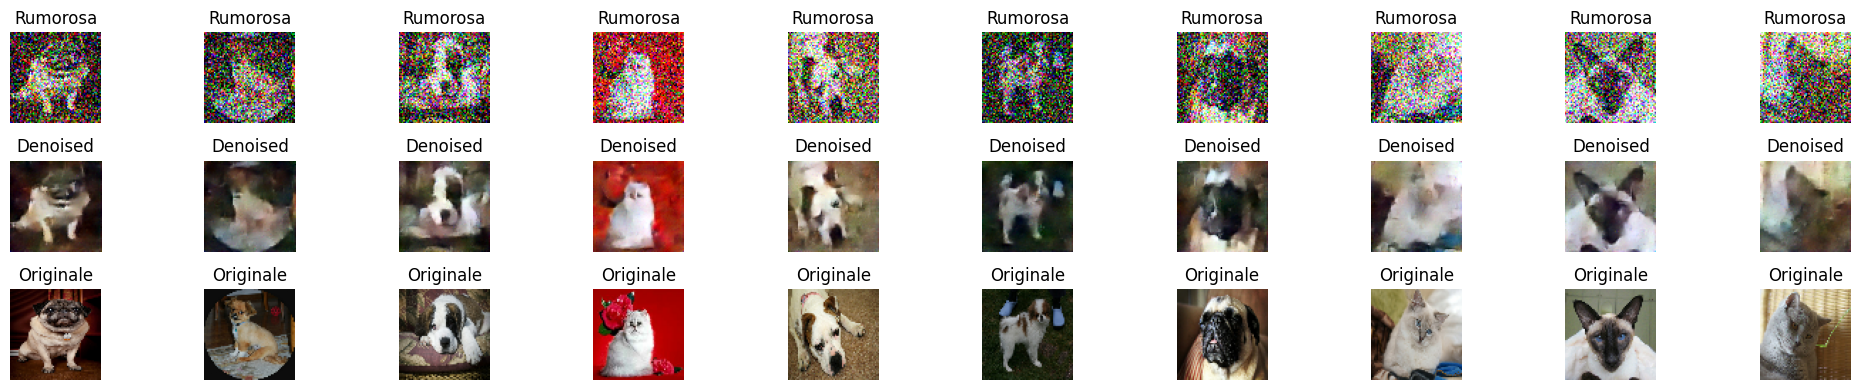

[np.float64(26.269474327165447), np.float64(23.043847358836715), np.float64(21.33231463281591), np.float64(20.222709574333003)]


In [86]:
all_autoen_psnr = model_psnr_predict(model, test_ds)

/tmp/ipython-input-87-208766035.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


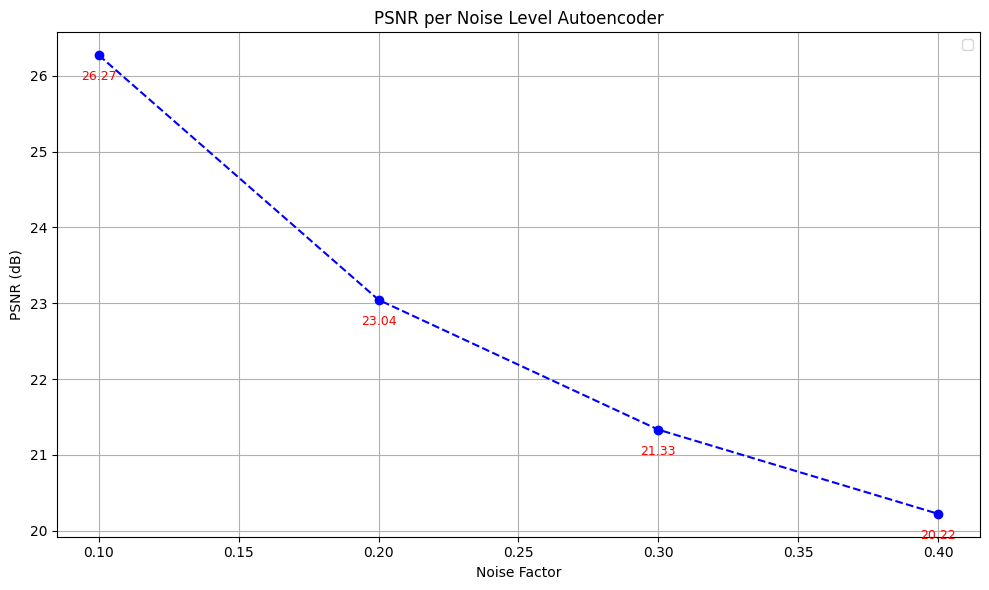

In [87]:
plt.figure(figsize=(10, 6))
noise_levels = [0.1, 0.2, 0.3, 0.4]
plt.plot(noise_levels, all_autoen_psnr, marker='o', linestyle='--', color='b')
for x, y in zip(noise_levels, all_autoen_psnr):
    plt.text(x, y - 0.2, f"{y:.2f}", ha='center', va='top', fontsize=9, color='r')

plt.title("PSNR per Noise Level Autoencoder")
plt.xlabel("Noise Factor")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
print(*[f"psnr: {val1}, noise: {val2}" for val1, val2 in zip(all_autoen_psnr, noise_levels)], sep='\n')


psnr: 26.269474327165447, noise: 0.1
psnr: 23.043847358836715, noise: 0.2
psnr: 21.33231463281591, noise: 0.3
psnr: 20.222709574333003, noise: 0.4
